# Assignment 2

**Keywords**: Sexism Detection, Multi-class Classification, LLMs, Prompting

# Introduction

We are going to address the [EDOS Task B](https://github.com/rewire-online/edos) on sexism detection.

## Problem definition

Given an input text sentence, we are going to label the sentence as not-sexist or one of these four sexist categories: (1) threats, (2)  derogation, (3) animosity, (4) prejudiced discussion.

### Examples:

**Text**: *``Schedule a date with her, then don't show up. Then text her "GOTCHA B___H".''*

**Label**: Threats

**Text**: *``That’s completely ridiculous a woman flashing her boobs is not sexual assault in the slightest.''*

**Label**: Not sexist



## Approach

We will tackle the five-class classification task with LLMs.

In particular, we'll consider zero-/few-shot prompting approaches to assess the capability of some popular open-source LLMs on this task.

We are going to download LLMs from [Huggingface](https://huggingface.co/).

### Setup and Dependencies

In [48]:
%pip -q install -U transformers accelerate bitsandbytes

In [49]:
import pandas as pd
import numpy as np
import torch
import time
import random
import re
import gc
import copy
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score
from accelerate import Accelerator

### Huggingface Login

Once we have created an account and an access token, we need to login to Huggingface via code.

In [50]:
!hf auth login

After login, you can download all models associated with your access token in addition to those that are not protected by an access token.

In [51]:
accelerator = Accelerator()
device = accelerator.device

def free_memory():
    gc.collect()
    accelerator.free_memory()

### Data Loading

Since we are only interested in prompting, we do not require a train dataset.

We have preparared a small test set version of EDOS.

The ``data`` folder contains:

- ``a2_test.csv`` → a small test set of 300 samples.
- ``demonstrations.csv`` -> a batch of 1000 samples for few-shot prompting.

Both datasets contain a balanced number of sexist and not sexist samples.

We Load Both``a2_test.csv``and``demonstrations.csv`` and encode them into``pandas.DataFrame`` objects.

In [52]:
from google.colab import drive
drive.mount('/content/drive')
# Load test data
# test_df = pd.read_csv('data/a2_test.csv')
test_df = pd.read_csv('/content/drive/MyDrive/NLP_2/Data/a2_test.csv')
# sanity check (check the first 5 rows of the dataframe)
test_df.head()
cols = test_df.columns.tolist()
cols_formatted = ", ".join(cols[:-1]) + " and " + cols[-1]
print(f"The test set has {test_df.shape[0]} rows and each row has {cols_formatted} columns.")
print('The categories are: ',test_df['label_category'].unique())
print("Each category has the following counts: ",test_df['label_category'].value_counts())

# Map label categories to numeric labels for ground truth
label_to_id = {
    "not-sexist": 0,
    "threats": 1,
    "derogation": 2,
    "animosity": 3,
    "prejudiced": 4,
}

test_texts = test_df["text"].tolist()
test_labels = test_df["label_category"].map(label_to_id).tolist()

print("Label Mapping Strategy:")
for label, id_val in label_to_id.items():
    print(f"  • '{label}' mapped to ID: {id_val}")

# Load few-shot demonstrations
# demo_df = pd.read_csv('data/demonstrations.csv')
demo_df = pd.read_csv('/content/drive/MyDrive/NLP_2/Data/demonstrations.csv')
demo_df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
The test set has 300 rows and each row has rewire_id, text and label_category columns.
The categories are:  ['derogation' 'prejudiced' 'animosity' 'not-sexist' 'threats']
Each category has the following counts:  label_category
derogation    60
prejudiced    60
animosity     60
not-sexist    60
threats       60
Name: count, dtype: int64
Label Mapping Strategy:
  • 'not-sexist' mapped to ID: 0
  • 'threats' mapped to ID: 1
  • 'derogation' mapped to ID: 2
  • 'animosity' mapped to ID: 3
  • 'prejudiced' mapped to ID: 4


,rewire_id,text,label_sexist,label_category,label_vector,split
0,sexism2022_english-7417,female egg donors are allowed to be uggo as fu...,sexist,derogation,2.1 descriptive attacks,train
1,sexism2022_english-10155,My girlfriend is mentally retarded. Or if you ...,sexist,derogation,2.1 descriptive attacks,test
2,sexism2022_english-15154,Lock her UP!!!!,sexist,threats,1.2 incitement and encouragement of harm,train
3,sexism2022_english-13387,So you want to live in a world where women are...,sexist,animosity,"3.1 casual use of gendered slurs, profanities,...",dev
4,sexism2022_english-2990,"Special episode of Loomy Does Politics, by pop...",sexist,prejudiced,4.2 supporting systemic discrimination against...,train


According to our tests, few-shot prompting increases inference time by some minutes (we experimented with ``num_per_class`` $\in [2, 4]$).

In [53]:
def build_few_shot_demonstrations(demonstrations, num_per_class=3, seed=25):
    """
    Inputs:
      demonstrations: DataFrame wrapping demonstrations.csv
      num_per_class: number of demonstrations per class

    Outputs:
      list[str] demonstrations to inject into the prompt template
    """
    demo_strings = []

    for label_name, group_df in demonstrations.groupby("label_category"):
      n = min(num_per_class, len(group_df))
      sampled = group_df.sample(n=n, random_state=seed)

      for _, row in sampled.iterrows():
        text = str(row['text']).strip()
        label = str(row['label_category']).strip()
        formatted_demo = f"TEXT: {text}\nANSWER: {label}"
        demo_strings.append(formatted_demo)

    rng = random.Random(seed)
    rng.shuffle(demo_strings)

    return demo_strings

In [54]:
few_shot_demo_list = build_few_shot_demonstrations(demo_df)
few_shot_examples = "\n\n".join(few_shot_demo_list)
print("Few-shot examples preview:\n")
print(few_shot_examples)

Few-shot examples preview:

TEXT: Yeah I'll echo DrSleeper here; women are typically very gracious or hurt. &#x200B; &#x200B;
ANSWER: animosity

TEXT: Are you fucking brain damaged or are you just female?
ANSWER: derogation

TEXT: How dare you treat gay people and women as humans, shitlord? I for one will side with the people honor killing gay people and women. It's about Social Justice.
ANSWER: threats

TEXT: Odin raped all those giant women and mortal women with their consent.
ANSWER: prejudiced

TEXT: There is no way to do so without enslaving yourself to a woman and the state.
ANSWER: prejudiced

TEXT: [USER] I'll throw her a bone, she looked pretty good until 35-40. Better than most women can say.
ANSWER: animosity

TEXT: There will always in the back of one's mind,was it worth it or.not.although,thanks to our.brave men and women for your sacrifice you will get your reward in heaven.God bless
ANSWER: not-sexist

TEXT: Regarding her sign: America has been succeeding for quite a lon

# Model setup
Once the test data has been loaded, we have to setup the model pipeline for inference.

In particular, we have to:
- Setup a quantization configuration and Quantize the model to fit into a single-GPU limited hardware
- Load the model weights via huggingFace APIs


In [55]:
MODEL_CONFIGS = [
    # {
    #     "name": "meta-llama/Llama-3.1-8B-Instruct",
    #     "nickname": "llama"
    # },
    # {
    #     "name": "deepseek-ai/DeepSeek-R1-Distill-Qwen-7B",
    #     "nickname": "deepseek"
    # },
    {
        "name": "TinyLlama/TinyLlama-1.1B-Chat-v1.0",
        "nickname": "TinyLlama"
    },
    {
        "name": "microsoft/Phi-3-mini-4k-instruct",
        "nickname": "Phi3Mini"
    },

    {
        "name": "Qwen/Qwen3-1.7B",
        "nickname": "Qwen3"
    }
]

In [56]:
def load_model(model_name: str):
    """
    Loads a Language Model with device-specific optimization:
    - CUDA: 4-bit quantization via bitsandbytes
    - MPS: float16 weights (bnb quantization not supported reliably)
    - CPU: float32 weights
    Returns: (model, tokenizer)
    """
    print(f"Loading {model_name}")

    bnb_config = None
    device_map = None
    torch_dtype = torch.float32

    if device.type == "cuda":
        torch_dtype = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16
        bnb_config = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_use_double_quant=True,
            bnb_4bit_quant_type="nf4",
            bnb_4bit_compute_dtype=torch_dtype,
        )
        device_map = "auto"

    elif device.type == "mps":
        torch_dtype = torch.float16


    model_kwargs = dict(
        quantization_config=bnb_config,
        torch_dtype=torch_dtype,
        device_map=device_map,
        trust_remote_code=False,
        low_cpu_mem_usage=True,
    )

    model = AutoModelForCausalLM.from_pretrained(model_name, **model_kwargs)

    tokenizer = AutoTokenizer.from_pretrained(
        model_name,
        trust_remote_code=False,
    )

    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    tokenizer.padding_side = "left"

    model.config.pad_token_id = tokenizer.pad_token_id

    # Only move manually if we did NOT use quantization (bnb_config is None)
    if bnb_config is None:
        model.to(device)
    model.eval()
    return model, tokenizer


# Prompt setup
Prompting requires an input pre-processing phase where we convert each input example into a specific instruction prompt.

We use the following prompt templates to process input texts.

In [57]:
zero_shot_prompt = [
    {
        'role': 'system',
        'content': 'You are an annotator for sexism detection.'
    },
    {
        'role': 'user',
        'content': """Your task is to classify input text as not-sexist
         or sexist. If sexist, classify input text according to one
         of the following four categories: threats, derogation,
         animosity, prejudiced discussion.

         Below you find sexist categories definitions:
         Threats: the text expresses intent or desire to harm a woman.
         Derogation: the text describes a woman in a derogative manner.
         Animosity: the text contains slurs or insults towards a woman.
         Prejudiced discussion: the text expresses supports for
         mistreatment of women as individuals.

         Respond only by writing one of the following categories:
         not-sexist, threats, derogation, animosity, prejudiced.

        TEXT: {text}

        ANSWER:
        """
    }
]

We slightly change the prompt template as follows to perform few-shot prompting to see the impact of providing demonstration examples.

In [58]:
few_shot_prompt = [
    {
        'role': 'system',
        'content': 'You are an annotator for sexism detection.'
    },
    {
        'role': 'user',
        'content': """Your task is to classify input text as not-sexist
         or sexist. If sexist, classify input text according to one
         of the following four categories: threats, derogation,
         animosity, prejudiced discussion.

         Below you find sexist categories definitions:
         Threats: the text expresses intent or desire to harm a woman.
         Derogation: the text describes a woman in a derogative manner.
         Animosity: the text contains slurs or insults towards a woman.
         Prejudiced discussion: the text expresses supports for
         mistreatment of women as individuals.

         Respond only by writing one of the following categories:
         not-sexist, threats, derogation, animosity, prejudiced.

        EXAMPLES: {examples}

        TEXT: {text}

        ANSWER:
        """
    }
]

Here to modify prepare_prompts funciton in a way that supports also demonstration, here is what we do:

-   pass examples as input to function(it has a 'None' default value for zero-shot test data prepareation, that doesn't have examples)

-   when we want to format 'content' we check if we got any examples in input or it has still it default value "None", and If it has changed then we assign the "examples" value to the examples

-   Since the provided prompt has placeholders, we need to format the string to replace placeholders.

In [59]:
def prepare_prompts(texts, prompt_template, tokenizer, examples=""):
    """
    Task:
    Format input text samples into instructions prompts.

    Inputs:
      texts: list[str] input texts to classify via prompting
      prompt_template: the prompt template provided(list of role/content dicts)
      tokenizer: the transformers Tokenizer object instance associated
      with the chosen model card

      examples: optional. Either:
        - None (zero-shot)
        - str (same examples prepended for every text)
        - list[str] (one examples string per text)

    Output:
      list[str] instruction prompts ready to pass to the model
    """

    formatted_prompts = []

    has_chat_template = (
        hasattr(tokenizer, "apply_chat_template")
        and getattr(tokenizer, "chat_template", None) is not None
    )


    for text in texts:
        current_prompt = copy.deepcopy(prompt_template)
        # Replace {text} placeholder in the user message
        # Find the user role message and replace {text} with actual text
        for message in current_prompt:
            if message['role'] == 'user':
                # Insert text and (optionally) examples
                message['content'] = message['content'].format(
                    text=text.strip(),
                    examples=examples
                    )

        if has_chat_template:
            try:
                formatted = tokenizer.apply_chat_template(
                    current_prompt,
                    tokenize=False,
                    add_generation_prompt=True,
                    enable_thinking=False,
                )
            except TypeError:
                formatted = tokenizer.apply_chat_template(
                    current_prompt,
                    tokenize=False,
                    add_generation_prompt=True
                )

        else:
            parts = []
            for msg in current_prompt:
                parts.append(f"{msg['role'].upper()}:\n{msg['content'].strip()}\n")
            formatted = "\n".join(parts)

        formatted_prompts.append(formatted)

    return formatted_prompts

# Inference
Once the prompts are formated, we make an Inference loop and then we parse generated responses as follows:
- **0** if 'not-sexist'
- **1** if 'threats'
- **2** if 'derogation'
- **3** if 'animosity'
- **4** if 'prejudiced'
- **-1** if the model does not answer in either way

In [60]:
def generate_responses(model, tokenizer, prompt_examples, batch_size=4, max_new_tokens=20, max_length=2048):
    """
    Task:
    Make an Inference loop for the model: prompt the LLM model with each
    pre-processed sample and generate responses.

    Inputs:
      model: LLM model instance
      tokenizer: tokenizer associated with this model
      prompt_examples: list[str] prompts (already pre-processed)

    Outputs:
      list[str] generated responses
    """
    all_responses = []

    for i in range(0, len(prompt_examples), batch_size):
        batch_prompts = prompt_examples[i:i + batch_size]

        enc = tokenizer(
            batch_prompts,
            truncation=True,
            max_length=max_length,
            return_tensors="pt",
            padding=True,
        )

        enc = {k: v.to(device) for k, v in enc.items()}

        with torch.inference_mode():
            generated_ids = model.generate(
                **enc,
                max_new_tokens=max_new_tokens, #set the length of answer
                do_sample=False,
                pad_token_id=tokenizer.pad_token_id,
                eos_token_id=tokenizer.eos_token_id,
            )

        # removing the prompt and only returning the answer
        input_len = enc["input_ids"].shape[1]
        generated_only = generated_ids[:, input_len:]

        responses = tokenizer.batch_decode(generated_only, skip_special_tokens=True)
        all_responses.extend(responses)

    return all_responses


In [61]:
def process_response(response: str) -> int:
    """
    Task:
      Parse LLM model generated responses into a 5-class label id using label_to_id.

    Inputs:
      response: generated response from LLM

    Outputs:
      parsed classification response(Returns -1 if it cannot be parsed)
    """

    r = response.strip().lower()
    r = r.replace("_", "-")
    r = r.replace("not sexist", "not-sexist")
    r = r.replace("prejudiced discussion", "prejudiced")

    if r in label_to_id:
        return label_to_id[r]

    r2 = r.replace(" ", "-")
    if r2 in label_to_id:
        return label_to_id[r2]

    for label, label_id in label_to_id.items():
        pattern = label.replace("-", r"[-\s]?")
        if re.search(rf"\b{pattern}\b", r, flags=re.IGNORECASE):
            return label_id

    # Keyword fallbac
    if "not-sexist" in r or "not sexist" in r:
        return 0
    if "threat" in r:
        return 1
    if "derogat" in r:
        return 2
    if "animosit" in r:
        return 3
    if "prejudic" in r:
        return 4

    # Required fallback:
    return -1


### Zero-shot Inference
we provide the input text to classify and instruct the model to generate a response.

In [62]:
def zero_shot_inference(model_name: str, model, tokenizer):
    """
    Run zero-shot inference for one model/tokenizer pair.
    """
    print("\n" + "="*60)
    print(f"Running ZERO-SHOT inference with {model_name}")
    print("="*60)

    start_time = time.time()

    prompts = prepare_prompts(test_texts, zero_shot_prompt, tokenizer)
    responses = generate_responses(model, tokenizer, prompts)
    predictions = [process_response(r) for r in responses]

    elapsed = time.time() - start_time
    print(f"✓ {model_name} completed in {elapsed:.2f}s (avg {elapsed/len(test_texts):.3f}s/sample)")

    return {
        "responses": responses,
        "predictions": predictions,
        "ground_truth": test_labels,
        "inference_time": elapsed
    }

### Few-shot Inference
We are now interested in performing few-shot prompting to see the impact of providing demonstration examples.

In [63]:
def few_shot_inference(model_name: str, model, tokenizer):
    print("\n" + "="*60)
    print(f"Running FEW-SHOT inference with {model_name} (num_per_class={num_per_class})")
    print("="*60)

    start_time = time.time()

    prompts = prepare_prompts(
        texts=test_texts,
        prompt_template=few_shot_prompt,
        tokenizer=tokenizer,
        examples=few_shot_examples
    )

    responses = generate_responses(model, tokenizer, prompts)
    predictions = [process_response(r) for r in responses]

    elapsed = time.time() - start_time
    print(f"✓ {model_name} completed in {elapsed:.2f}s (avg {elapsed/len(test_texts):.3f}s/sample)")

    return {
        "responses": responses,
        "predictions": predictions,
        "ground_truth": test_labels,
        "inference_time": elapsed
    }

# Metrics
In order to evaluate selected LLMs, we need to compute performance metrics.

We compute :
-   **accuracy** : The ratio of correct responses generated by models.
-   **fail-ratio** : The ratio of invalid predictions generated by models.
-   **macro F1-score** : The harmonic mean of Precision and Recall

In [64]:
def compute_metrics(y_pred, y_true):
    """
    Task:
      Compute accuracy, macro F1-score, and fail-ratio.

    Inputs:
      y_pred: parsed LLM responses
      y_true: ground-truth binary labels

    Outputs:
      dictionary containing desired metrics
    """
    y_pred = np.array(y_pred, dtype=int)
    y_true = np.array(y_true, dtype=int)

    # fail_ratio = failed predictions/all predictions
    fail_ratio = np.mean(y_pred == -1)

    # accuracy = correct predictions/all samples
    accuracy = accuracy_score(y_true, y_pred)


    # we should remove the invalid responses(-1)
    valid_mask = (y_pred != -1)
    y_pred_filtered = y_pred[valid_mask]
    y_true_filtered = y_true[valid_mask]

    # for each class,F1-score = 2*precision*recall/(precision+recall)
    # precision = TP/PP(TP+FP) and recall = TP/AP(TP+FN)
    #TP: true positive, FP: false positive, FN: false negative, TN: true negative, PP: predicted positive(TP+FP), AP: actual positive(TP+FN)
    macro_f1 = f1_score(
        y_true_filtered,
        y_pred_filtered,
        average="macro",
        labels=[0, 1, 2, 3, 4],
        zero_division=0
    )

    return {
        "accuracy": float(accuracy),
        "macro_f1": float(macro_f1),
        "fail_ratio": float(fail_ratio),
    }

# Error Analysis
We are now interested in evaluating model responses and comparing their performance.

This analysis helps us in understanding

- Classification task performance gap: are the models good at this task?
- Generation quality: which kind of responses do models generate?
- Errors: which kind of mistakes do models do?



In order to get Task 6 points, we require you to:

* Compare classification performance of selected LLMs in a Table.
* Compute confusion matrices for selected LLMs.
* Briefly summarize your observations on generated responses.

In [65]:
id2label = {v: k for k, v in label_to_id.items()}
LABEL_IDS = [0, 1, 2, 3, 4]
LABEL_NAMES = [id2label[i] for i in LABEL_IDS]

### Build performance table

In [66]:
def performance_table():
  rows = []
  for model_name, tasks in model_results.items():

      for task_type, task_data in tasks.items():
          rows.append({
              "Model": model_name,
              "Setting": task_type,
              "Accuracy": task_data["metrics"].get("accuracy", 0),
              "Macro F1": task_data["metrics"].get("macro_f1", 0),
              "Fail Ratio": task_data["metrics"].get("fail_ratio", 0),
              "Inference Time (s)": task_data["inference_time"]
          })

  # 4. Create and display the DataFrame
  df_results = pd.DataFrame(rows)

  # Optional: Sort for better readability
  df_results = df_results.sort_values(by=["Model", "Setting"]).reset_index(drop=True)

  print(df_results)
  # If using Jupyter/Colab, just write: df_results

In [67]:
def plot_confusion_matrix(results, title):
    y_true = np.array(results["ground_truth"], dtype=int)
    y_pred = np.array(results["predictions"], dtype=int)

    fail_ratio = np.mean(y_pred == -1)
    y_pred_eval = y_pred.copy()
    y_pred_eval[y_pred_eval == -1] = 0

    cm = confusion_matrix(y_true, y_pred_eval, labels=LABEL_IDS)

    plt.figure(figsize=(7, 6))
    plt.imshow(cm, interpolation="nearest")
    plt.title(f"{title} (fail={fail_ratio:.1%})")
    plt.colorbar()
    tick_marks = np.arange(len(LABEL_NAMES))
    plt.xticks(tick_marks, LABEL_NAMES, rotation=45, ha="right")
    plt.yticks(tick_marks, LABEL_NAMES)

    thresh = cm.max() * 0.6 if cm.max() > 0 else 1
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            val = cm[i, j]
            plt.text(j, i, str(val),
                     ha="center", va="center",
                     color="white" if val > thresh else "black")

    plt.ylabel("True")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.show()

Observations on Generated Responses

1. Instruction Following & Hallucination (Zero-Shot)

TinyLlama (1.1B): The model struggled significantly with the zero-shot instructions. Instead of classifying the text, it frequently repeated the definitions provided in the system prompt (e.g., outputting "Sexist categories definitions: Threats..."). This resulted in a high Fail Ratio (42%) and very poor accuracy (~12%), as the model failed to generate a parseable label.

Phi-3 (3.8B): In contrast, Phi-3 demonstrated excellent instruction-following capabilities. It consistently generated valid, concise labels (e.g., "derogation", "prejudiced") without hallucinating definitions, achieving a 0% Fail Ratio and significantly higher accuracy (~42%).

2. Impact of Few-Shot Prompting

Format Correction: Few-shot prompting was critical for TinyLlama. Providing examples successfully "taught" the model the required output format (e.g., ANSWER: threats), causing the Fail Ratio to drop from 42% to 0%.

Performance: While few-shot prompting fixed the syntax errors for TinyLlama, its classification accuracy remained low (~20%), suggesting that while it could mimic the format, it still struggled to distinguish between the complex definitions of sexism compared to the more capable Phi-3.

3. Conclusion The experiment highlights that smaller models like TinyLlama require few-shot demonstrations to understand output constraints, whereas more capable models like Phi-3 can handle complex classification tasks effectively in a zero-shot setting.



"TinyLlama is an older/smaller architecture (1.1B) and lacks the strong instruction-following capabilities required for the complex definitions in Zero-shot."

"Phi-3 (3.8B), despite being small, has been trained on high-quality 'textbook quality' data, allowing it to understand the task without examples."

In [68]:
def nll_true_label_for_samples(model, tokenizer, prompts, true_label_ids, max_length=2048):
    """
    Compute per-sample NLL of the true label string given the prompt.
    Returns an array of NLL values aligned with prompts.
    """
    true_label_strs = [id2label[int(i)] for i in true_label_ids]

    nll = np.zeros(len(prompts), dtype=float)

    for lbl in LABEL_NAMES:
        idx = [i for i, t in enumerate(true_label_strs) if t == lbl]
        if not idx:
            continue

        sub_prompts = [prompts[i] for i in idx]

        enc = tokenizer(
            sub_prompts,
            truncation=True,
            max_length=max_length,
            return_tensors="pt",
            padding=True,
        )
        enc = {k: v.to(device) for k, v in enc.items()}

        label_ids = tokenizer(lbl, add_special_tokens=False)["input_ids"]
        label_ids = torch.tensor(label_ids, dtype=torch.long, device=device)

        with torch.inference_mode():
            for b in range(enc["input_ids"].shape[0]):
                input_ids = enc["input_ids"][b]
                attn = enc["attention_mask"][b]
                prompt_len = int(attn.sum().item())
                prompt_ids = input_ids[:prompt_len]

                full_ids = torch.cat([prompt_ids, label_ids], dim=0).unsqueeze(0)
                out = model(full_ids)
                logits = out.logits
                log_probs = torch.log_softmax(logits, dim=-1)

                this_nll = 0.0
                for t, tok_id in enumerate(label_ids):
                    pos = prompt_len + t - 1
                    this_nll -= float(log_probs[0, pos, tok_id].item())

                nll[idx[b]] = this_nll

    return nll

In [69]:
def error_analysis_from_existing_results(model_name, model, tokenizer, results, prompt_template, examples=None, setting="zero-shot", top_k=10):
    """
    Uses already-generated predictions/responses from `results`,
    and only adds a dataframe + NLL-based top errors.
    """
    prompts = prepare_prompts(test_texts, prompt_template, tokenizer, examples=examples)

    y_true = np.array(results["ground_truth"], dtype=int)
    raw_pred = np.array(results["predictions"], dtype=int)
    y_pred_eval = raw_pred.copy()
    y_pred_eval[y_pred_eval == -1] = 0

    df = pd.DataFrame({
        "text": test_texts,
        "true_id": y_true,
        "pred_id": y_pred_eval,
        "raw_pred_id": raw_pred,
        "raw_response": results["responses"]
    })
    df["true_label"] = df["true_id"].map(id2label)
    df["pred_label"] = df["pred_id"].map(id2label)
    df["is_fail"] = (df["raw_pred_id"] == -1)

    df["nll_true_label"] = nll_true_label_for_samples(model, tokenizer, prompts, y_true)

    wrong = df[df["true_id"] != df["pred_id"]].copy()
    top_errors = wrong.sort_values("nll_true_label", ascending=False).head(top_k)

    print("\n" + "="*80)
    print(f"{model_name} — {setting}")
    print("="*80)
    print(f"Fails: {df['is_fail'].mean():.3f} | Wrong: {(df['true_id'] != df['pred_id']).mean():.3f}")
    print("\nTop errors (highest NLL of true label):")
    with pd.option_context("display.max_colwidth", None):
        display(top_errors[["text", "true_label", "pred_label", "raw_response", "nll_true_label"]])

    return {
        "df": df,
        "top_errors": top_errors
    }

**Phi3Mini performs best overall**, with its best result in **zero-shot** (Accuracy **0.42**, Macro F1 **0.390**), while **Qwen3** is second (best zero-shot: Accuracy **0.29**, Macro F1 **0.215**) and **TinyLlama** is worst (best zero-shot: Accuracy **0.23**, Macro F1 **0.132**) and also has many invalid outputs in zero-shot (**fail ratio 41.3%**). **Few-shot removes TinyLlama’s failures (0% fail)** but does not improve classification, and it slightly **reduces performance for Phi3Mini and Qwen3** while increasing inference time (especially for Phi3Mini: **830s** vs **358s**). The confusion matrices show **Qwen3 strongly over-predicts “derogation” and almost never predicts “animosity”**, whereas **Phi3Mini is more balanced** but still struggles most with **“derogation”** (often confused with **animosity/prejudiced**). In few-shot, **TinyLlama collapses to predicting “not-sexist” for every sample**, explaining its **0.20** accuracy on this balanced dataset.

### Bonus Points

0.5 bonus points are arbitrarily assigned based on significant contributions such as:

- Outstanding error analysis
- Masterclass code organization
- Evaluate A1 dataset and perform comparison
- Perform prompt tuning

Note that bonus points are only assigned if all task points are attributed (i.e., 6/6).

Starting Master Pipeline...

Processing TinyLlama...
Loading TinyLlama/TinyLlama-1.1B-Chat-v1.0

Running ZERO-SHOT inference with TinyLlama/TinyLlama-1.1B-Chat-v1.0
✓ TinyLlama/TinyLlama-1.1B-Chat-v1.0 completed in 106.71s (avg 0.356s/sample)

Running FEW-SHOT inference with TinyLlama/TinyLlama-1.1B-Chat-v1.0 (num_per_class=3)
✓ TinyLlama/TinyLlama-1.1B-Chat-v1.0 completed in 107.95s (avg 0.360s/sample)

TinyLlama (zero_shot) Results:
Accuracy:   0.1267
Macro F1:   0.0950
Fail Ratio: 0.3967

TinyLlama (few_shot) Results:
Accuracy:   0.2000
Macro F1:   0.0667
Fail Ratio: 0.0000


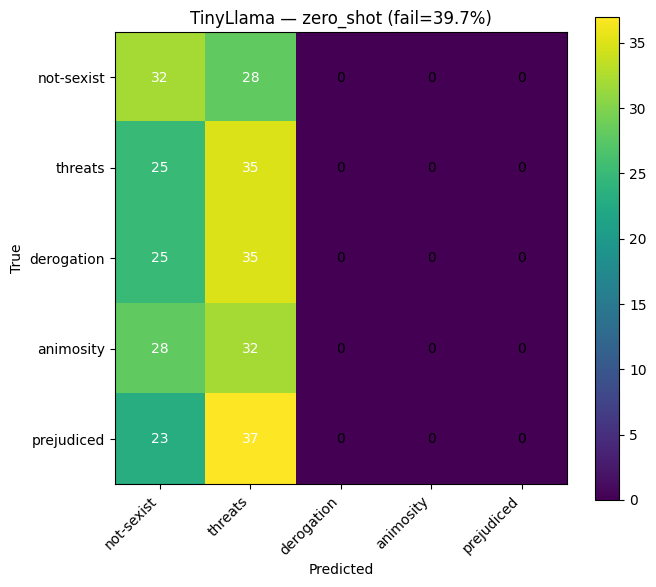

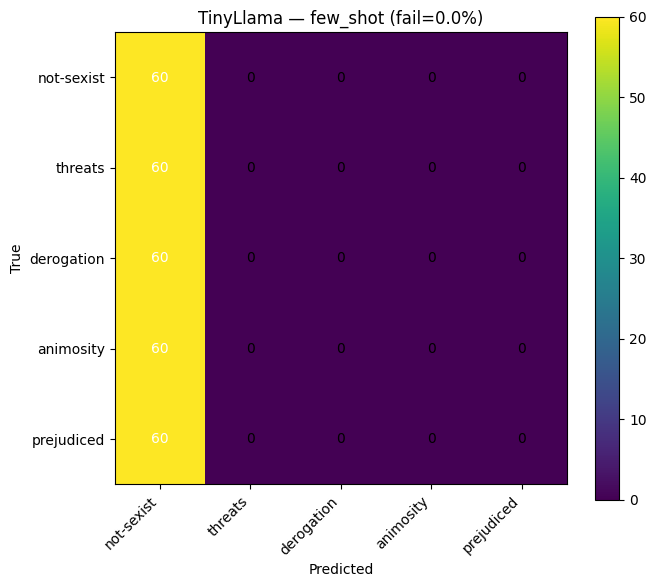

  - Running Error Analysis...

TinyLlama — zero-shot
Fails: 0.397 | Wrong: 0.777

Top errors (highest NLL of true label):


,text,true_label,pred_label,raw_response,nll_true_label
85,"dudes are tripping when they say an escort would be safer. These bitches suck 10+ daily, have random dudes fingers in their pussies, do bareback with some clients (no exagerration). no way an escort is safer than a non escort IMO",derogation,not-sexist,Input text: Dudes are tripping when they say an escort would be safer. These,36.363281
126,"Let’s make an all female cast star wars movie, directed by Paul Feig, starring the cast of the 2016 ’blockbuster’ hit Ghostbusters! It’s Ghostbusters.. in space, with like lasers and stronk whamen & stuff.",animosity,not-sexist,"Your input text ""Let's make an all female cast star wars movie, directed by Paul Fe",33.227905
82,"Don't think that using the word ""feminine"" wasn't strategic, Mo. It was. And I couldn't agree more with everything else you wrote. They attempt to bring the rest of us down to their level. Not gonna happen ... Lol, men are a gift from God.",animosity,not-sexist,"Input: ""Don't think that using the word 'feminine' wasn't",32.970444
37,Buy the ring. Insure it. Let her wear it for awhile. Pay someone to steal from her. Collect the insurance. Split the resale value with the thief. She will be too scared to want a big ring. Buy a cheap band. Turn a profit.,threats,not-sexist,"Your input text ""Buy the ring. Insure it. Let her wear it for awhile",29.926025
190,"In vitro fertilization. Even if it's a terrible idea for the child's development, a woman with baby rabies doesn't give a shit. We'll see what happens. Crushing birth control pills in her drinks is a good option.",threats,not-sexist,Input text: In vitro fertilization. Even if it's a terrible idea for the,29.699219
144,"[URL] Commie, & closet muslim stooge Clooney, speaks muslim lies & propaganda thru his wife's muslim vagina that spews sharia hell for women. Hollywood loves muslim hell & hates America that makes them free &rich!",animosity,not-sexist,"Your input text, ""Commie, & closet muslim stooge Clooney, speaks",29.250657
76,"Yeah, he makes a 6 figure salary and she has this grand ""plan"" for him, he pussy blind enough to thinks it's great. And to be honest the plan is what every man wants... Guess she's a NAWALT. .... Lol and unicorns exist too.",animosity,threats,Sexist categories definitions:\n\nThreats: The text expresses intent or desire to,29.125142
207,"Too right this creep should be denied a visa. How is it even out of gaol? And how does a so-called female have an Adam's apple & probably other male bits? Lastly, our immigration policy is none of your fucking business you freak. [URL]",threats,not-sexist,Input: Too right this creep should be denied a visa. How is it even out,27.251541
191,"#BritFam Brit HIGH court recognizes Sharia Marriage, but only so wife can divorce rape husbands a$$ets case of leftists choosing the path which screwed a man, more than leftists trying to recognize Sharia [USER] [USER] [URL]",prejudiced,not-sexist,"To classify the input text as not-sexist or sexist, you can follow the four",26.367188
46,"Yeah some high ranking cunt periodically deletes perfectly well sourced entries. Her ~~sandbox~~ user page was recently vandalized and I tell you, internet crime is outta control these days. I hope she is able to recover. [URL]",animosity,not-sexist,"Input:\n""Yeah some high ranking cunt periodically deletes perfectly well sour",25.384872



TinyLlama — few-shot
Fails: 0.000 | Wrong: 0.800

Top errors (highest NLL of true label):


,text,true_label,pred_label,raw_response,nll_true_label
85,"dudes are tripping when they say an escort would be safer. These bitches suck 10+ daily, have random dudes fingers in their pussies, do bareback with some clients (no exagerration). no way an escort is safer than a non escort IMO",derogation,not-sexist,"To classify input text as not-sexist, you need to follow the four categories defined by",32.324219
126,"Let’s make an all female cast star wars movie, directed by Paul Feig, starring the cast of the 2016 ’blockbuster’ hit Ghostbusters! It’s Ghostbusters.. in space, with like lasers and stronk whamen & stuff.",animosity,not-sexist,"To classify the input text as not-sexist, you need to follow the four categories defined",30.645752
144,"[URL] Commie, & closet muslim stooge Clooney, speaks muslim lies & propaganda thru his wife's muslim vagina that spews sharia hell for women. Hollywood loves muslim hell & hates America that makes them free &rich!",animosity,not-sexist,"To classify the input text as not-sexist, you need to follow the four categories defined",29.628619
82,"Don't think that using the word ""feminine"" wasn't strategic, Mo. It was. And I couldn't agree more with everything else you wrote. They attempt to bring the rest of us down to their level. Not gonna happen ... Lol, men are a gift from God.",animosity,not-sexist,"To classify the input text as not-sexist, you need to follow the four categories defined",28.878540
191,"#BritFam Brit HIGH court recognizes Sharia Marriage, but only so wife can divorce rape husbands a$$ets case of leftists choosing the path which screwed a man, more than leftists trying to recognize Sharia [USER] [USER] [URL]",prejudiced,not-sexist,"To classify the input text as not-sexist, you need to follow the four categories defined",27.812500
76,"Yeah, he makes a 6 figure salary and she has this grand ""plan"" for him, he pussy blind enough to thinks it's great. And to be honest the plan is what every man wants... Guess she's a NAWALT. .... Lol and unicorns exist too.",animosity,not-sexist,"To classify the input text as not-sexist, you need to follow the four categories defined",26.750545
28,"[URL] Muslims home roots no need for women , closed their holes . Genital mutilation , Infections & death is what a women deserve they rather fuck boys & goats. Sex with women is anal anyway . Muslims culture is beautiful homos that act like real men",threats,not-sexist,"To classify input text as not-sexist, you need to follow the four categories defined by",26.394531
133,"Hi Amelia, your site is fucking garbage. Please kill yourself.",threats,not-sexist,"To classify the input text as not-sexist, you need to follow the four categories defined",26.027588
155,Let the females die from the elements as punishment for their slut nature.,threats,not-sexist,"To classify the input text as not-sexist, you need to identify the four categories of",26.027588
182,Arrest the bitch and put her in a cell with male rapists.,threats,not-sexist,"To classify input text as not-sexist, you need to follow the four categories defined by",26.027588


       Model    Setting  Accuracy  Macro F1  Fail Ratio  Inference Time (s)
0  TinyLlama   few_shot  0.200000  0.066667    0.000000          107.948484
1  TinyLlama  zero_shot  0.126667  0.094959    0.396667          106.711909
Processing Phi3Mini...
Loading microsoft/Phi-3-mini-4k-instruct


...

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/306 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/599 [00:00<?, ?B/s]


Running ZERO-SHOT inference with microsoft/Phi-3-mini-4k-instruct
✓ microsoft/Phi-3-mini-4k-instruct completed in 30.45s (avg 0.101s/sample)

Running FEW-SHOT inference with microsoft/Phi-3-mini-4k-instruct (num_per_class=3)
✓ microsoft/Phi-3-mini-4k-instruct completed in 43.95s (avg 0.146s/sample)

Phi3Mini (zero_shot) Results:
Accuracy:   0.4200
Macro F1:   0.3901
Fail Ratio: 0.0000

Phi3Mini (few_shot) Results:
Accuracy:   0.4000
Macro F1:   0.3683
Fail Ratio: 0.0000


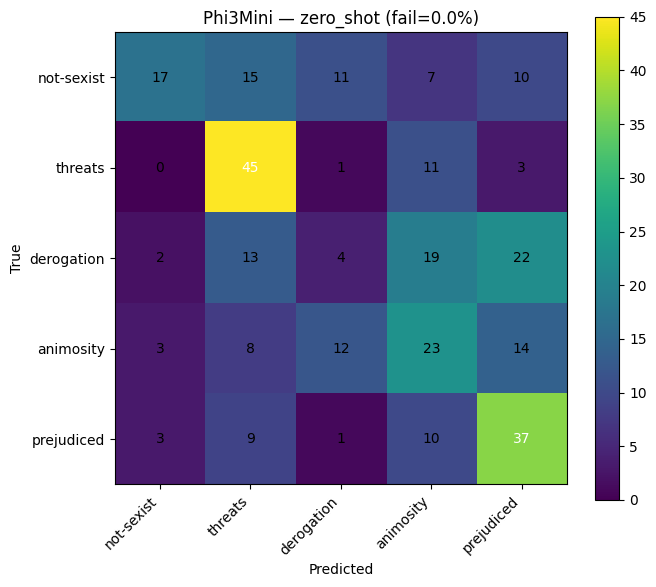

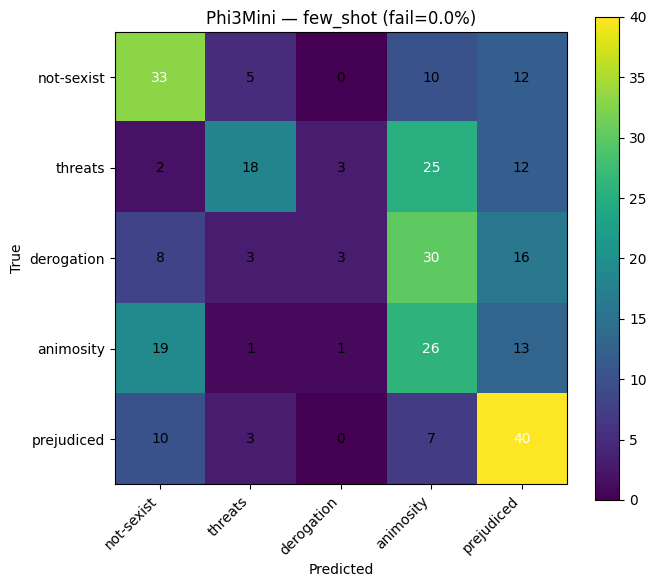

  - Running Error Analysis...

Phi3Mini — zero-shot
Fails: 0.000 | Wrong: 0.580

Top errors (highest NLL of true label):


,text,true_label,pred_label,raw_response,nll_true_label
190,"In vitro fertilization. Even if it's a terrible idea for the child's development, a woman with baby rabies doesn't give a shit. We'll see what happens. Crushing birth control pills in her drinks is a good option.",threats,animosity,animosity,39.501587
126,"Let’s make an all female cast star wars movie, directed by Paul Feig, starring the cast of the 2016 ’blockbuster’ hit Ghostbusters! It’s Ghostbusters.. in space, with like lasers and stronk whamen & stuff.",animosity,prejudiced,prejudiced,39.009383
85,"dudes are tripping when they say an escort would be safer. These bitches suck 10+ daily, have random dudes fingers in their pussies, do bareback with some clients (no exagerration). no way an escort is safer than a non escort IMO",derogation,animosity,animosity,38.516052
80,"Who's cock is she sucking? If it's not yours she is not interested, period.",derogation,threats,threats,35.375000
195,"maybe in the old days girls like this would be worth it because they were virgins, weren't hoes, were loyal, didn't go out to bars and didn't cheat. But the ""modern woman"" who ""explores her sexuality""? Hell no. That's worthless",derogation,animosity,animosity,34.505875
183,well..well..well.. what do we have here. The dumbest motherfucker to ever serve in congress just revealed state secrets live at her press conference. Hang this fucking traitor. [URL],threats,animosity,animosity,31.804688
191,"#BritFam Brit HIGH court recognizes Sharia Marriage, but only so wife can divorce rape husbands a$$ets case of leftists choosing the path which screwed a man, more than leftists trying to recognize Sharia [USER] [USER] [URL]",prejudiced,animosity,animosity,27.757355
286,To rationalize being an arrogant selfish prick.,not-sexist,threats,threats,27.248047
117,"If the mother had an ~~fortunate~~ unfortunate accident, it would be a real shame.",threats,derogation,derogation,26.389709
271,It's so easy. Just have a vagina at birth and you'll be treated like a princess for life.,derogation,prejudiced,prejudiced,25.992188



Phi3Mini — few-shot
Fails: 0.000 | Wrong: 0.600

Top errors (highest NLL of true label):


,text,true_label,pred_label,raw_response,nll_true_label
126,"Let’s make an all female cast star wars movie, directed by Paul Feig, starring the cast of the 2016 ’blockbuster’ hit Ghostbusters! It’s Ghostbusters.. in space, with like lasers and stronk whamen & stuff.",animosity,not-sexist,not-sexist,29.451324
190,"In vitro fertilization. Even if it's a terrible idea for the child's development, a woman with baby rabies doesn't give a shit. We'll see what happens. Crushing birth control pills in her drinks is a good option.",threats,prejudiced,prejudiced,29.403687
144,"[URL] Commie, & closet muslim stooge Clooney, speaks muslim lies & propaganda thru his wife's muslim vagina that spews sharia hell for women. Hollywood loves muslim hell & hates America that makes them free &rich!",animosity,prejudiced,prejudiced,27.500793
183,well..well..well.. what do we have here. The dumbest motherfucker to ever serve in congress just revealed state secrets live at her press conference. Hang this fucking traitor. [URL],threats,animosity,animosity,26.808594
212,"I don't see him as #1. He loves getting them worked into a distracted frenzy - he has proven to do his best work while they're freaking out over something he may have said, or his wife's stilettos.",not-sexist,animosity,animosity,25.149658
195,"maybe in the old days girls like this would be worth it because they were virgins, weren't hoes, were loyal, didn't go out to bars and didn't cheat. But the ""modern woman"" who ""explores her sexuality""? Hell no. That's worthless",derogation,prejudiced,prejudiced,25.033386
110,"Original link here, complete with ""arty"" photographs of the mutilator hard at work: [URL] This article is so full of utter evil filth, it's hard to know where to start. God help all these infant boys she is raping, mutilating and sexually abusing.",not-sexist,threats,threats,24.940674
115,"Yes. Especially these days, it takes a lot to make a man beat a woman. Dont buy into her bullshit. She probably deserve. At least hear the version of the guy. I would make an exception if it was a severe beating.",threats,prejudiced,prejudiced,24.843750
150,"""The progress of 'modern art' --A Jew dances with a Prostitute."" A painter holds a palette bearing the words Schulchan Aruch (a medieval compendium of Jewish law). Behind the naked female dancer is the word Judaismus (Judaism).",not-sexist,prejudiced,prejudiced,24.656738
2,Two thoughts to keep in mind about women and AA. 1) Show me a hot girl and I'll show you a man sick of all her bullshit. 2) She has messy diarrhea and loud farts just like the rest of us.,derogation,animosity,animosity,24.570312


       Model    Setting  Accuracy  Macro F1  Fail Ratio  Inference Time (s)
0   Phi3Mini   few_shot  0.400000  0.368308    0.000000           43.945642
1   Phi3Mini  zero_shot  0.420000  0.390117    0.000000           30.449606
2  TinyLlama   few_shot  0.200000  0.066667    0.000000          107.948484
3  TinyLlama  zero_shot  0.126667  0.094959    0.396667          106.711909
Processing Qwen3...
Loading Qwen/Qwen3-1.7B


...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



Running ZERO-SHOT inference with Qwen/Qwen3-1.7B
✓ Qwen/Qwen3-1.7B completed in 29.91s (avg 0.100s/sample)

Running FEW-SHOT inference with Qwen/Qwen3-1.7B (num_per_class=3)
✓ Qwen/Qwen3-1.7B completed in 31.69s (avg 0.106s/sample)

Qwen3 (zero_shot) Results:
Accuracy:   0.2867
Macro F1:   0.2143
Fail Ratio: 0.0000

Qwen3 (few_shot) Results:
Accuracy:   0.3300
Macro F1:   0.2631
Fail Ratio: 0.0033


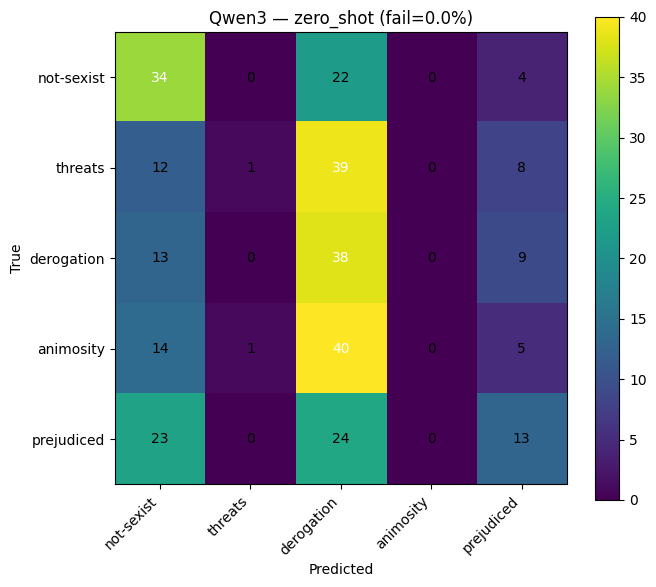

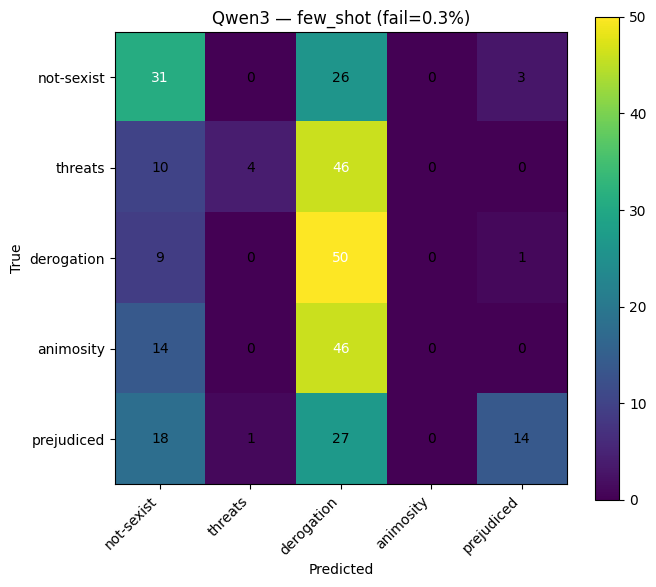

  - Running Error Analysis...

Qwen3 — zero-shot
Fails: 0.000 | Wrong: 0.713

Top errors (highest NLL of true label):


,text,true_label,pred_label,raw_response,nll_true_label
222,"Like with the beautiful women who never knew life was cruel. Incels can’t comprehend that women and sex are not the prize. Even women know that men are the prize. From controlling and enslaving men, is the only way women get power and wealth.",derogation,prejudiced,prejudiced,79.000000
196,"He's got it backwards, we need STRONG men and GOOD women.",animosity,derogation,derogation,62.125000
116,"It's why we dress women up, romanticize and idealize them, etc. All of it obscures the ugly truth of it. And so long as you have functioning monogamous marriage, men never have to know better. Nobody benefits more than women themselves.",prejudiced,not-sexist,not-sexist,55.127991
193,"""Why women the size of whales shouldn't be allowed to drive"" by [USER] [URL]",derogation,not-sexist,not-sexist,51.511230
254,40 years of your fat mom on welfare is reparations you lazy low iq bitch,derogation,not-sexist,not-sexist,50.812504
278,"White men letting groids, juice, and women run wild was the beginning of the end.",derogation,not-sexist,not-sexist,50.812504
144,"[URL] Commie, & closet muslim stooge Clooney, speaks muslim lies & propaganda thru his wife's muslim vagina that spews sharia hell for women. Hollywood loves muslim hell & hates America that makes them free &rich!",animosity,prejudiced,prejudiced,49.509094
98,[USER] Science will have to invent a new form of math just to quantify her ego. Maybe under a president Trump the only place she'll be leaving to is a prison. Let her bitch about the patriarchy from cell block C.,animosity,derogation,derogation,48.990234
53,Kurds are drug addict commies and there is no way they wouldn’t molest a white girl.,not-sexist,derogation,derogation,48.625232
256,3 hot girls and you think of fecal toilet comments! You must be a jew. SMDH,not-sexist,derogation,derogation,48.625149



Qwen3 — few-shot
Fails: 0.003 | Wrong: 0.670

Top errors (highest NLL of true label):


,text,true_label,pred_label,raw_response,nll_true_label
222,"Like with the beautiful women who never knew life was cruel. Incels can’t comprehend that women and sex are not the prize. Even women know that men are the prize. From controlling and enslaving men, is the only way women get power and wealth.",derogation,prejudiced,prejudiced,82.500000
144,"[URL] Commie, & closet muslim stooge Clooney, speaks muslim lies & propaganda thru his wife's muslim vagina that spews sharia hell for women. Hollywood loves muslim hell & hates America that makes them free &rich!",animosity,derogation,derogation,55.501579
98,[USER] Science will have to invent a new form of math just to quantify her ego. Maybe under a president Trump the only place she'll be leaving to is a prison. Let her bitch about the patriarchy from cell block C.,animosity,derogation,derogation,55.014709
116,"It's why we dress women up, romanticize and idealize them, etc. All of it obscures the ugly truth of it. And so long as you have functioning monogamous marriage, men never have to know better. Nobody benefits more than women themselves.",prejudiced,not-sexist,not-sexist,48.250105
240,#Politics #GabFam #MAGA #Australia As #MSM develops a case of total silence while covering womens virtue signaling BS. Must've been the vagina hats rather than the FGM and child RAPES [URL],derogation,not-sexist,not-sexist,47.062500
111,"Yes, because she made a mistake,she SHOULD pay for it. It was her mistake not society's. I'm all for legit help for someone in need but people who fuck around, don't use protection and then expect to get bailed out can go screw",prejudiced,derogation,derogation,46.938118
190,"In vitro fertilization. Even if it's a terrible idea for the child's development, a woman with baby rabies doesn't give a shit. We'll see what happens. Crushing birth control pills in her drinks is a good option.",threats,derogation,derogation,46.500004
28,"[URL] Muslims home roots no need for women , closed their holes . Genital mutilation , Infections & death is what a women deserve they rather fuck boys & goats. Sex with women is anal anyway . Muslims culture is beautiful homos that act like real men",threats,derogation,derogation,46.250000
95,"Ugh, that fucking sucks, especially when you come to the realization that a bunch of the times you were all done hanging out for the night and going your separate ways, they were actually waiting for you to leave so he could get balls deep in her.",not-sexist,derogation,derogation,44.531783
100,"And there is a reason to believe him. The tingles she gets from being around him and by believing him she doesn't have to feel ""guilt"" for being the side ho.",animosity,derogation,derogation,43.125000


       Model    Setting  Accuracy  Macro F1  Fail Ratio  Inference Time (s)
0   Phi3Mini   few_shot  0.400000  0.368308    0.000000           43.945642
1   Phi3Mini  zero_shot  0.420000  0.390117    0.000000           30.449606
2      Qwen3   few_shot  0.330000  0.263094    0.003333           31.687445
3      Qwen3  zero_shot  0.286667  0.214318    0.000000           29.912174
4  TinyLlama   few_shot  0.200000  0.066667    0.000000          107.948484
5  TinyLlama  zero_shot  0.126667  0.094959    0.396667          106.711909


In [75]:
model_results = {}
analysis_outputs = {}
num_per_class = 3
metrics = {}

print("Starting Master Pipeline...\n")

for cfg in MODEL_CONFIGS:
  nickname = cfg["nickname"]
  model_name = cfg["name"]

  print(f"Processing {nickname}...")

  model,tokenizer = load_model(model_name)

  model_results[nickname] = {}
  model_results[nickname]['zero_shot'] = zero_shot_inference(model_name, model,tokenizer)
  model_results[nickname]['few_shot'] = few_shot_inference(model_name, model,tokenizer)

  model_results[nickname]['zero_shot']["metrics"] = compute_metrics(model_results[nickname]['zero_shot']["predictions"],model_results[nickname]['zero_shot']["ground_truth"])
  model_results[nickname]['few_shot']["metrics"] = compute_metrics(model_results[nickname]['few_shot']["predictions"],model_results[nickname]['few_shot']["ground_truth"])

  print(f"\n{nickname} (zero_shot) Results:")
  print(f"Accuracy:   {model_results[nickname]['zero_shot']["metrics"]['accuracy']:.4f}")
  print(f"Macro F1:   {model_results[nickname]['zero_shot']["metrics"]['macro_f1']:.4f}")
  print(f"Fail Ratio: {model_results[nickname]['zero_shot']["metrics"]['fail_ratio']:.4f}")

  print(f"\n{nickname} (few_shot) Results:")
  print(f"Accuracy:   {model_results[nickname]['few_shot']["metrics"]['accuracy']:.4f}")
  print(f"Macro F1:   {model_results[nickname]['few_shot']["metrics"]['macro_f1']:.4f}")
  print(f"Fail Ratio: {model_results[nickname]['few_shot']["metrics"]['fail_ratio']:.4f}")

  plot_confusion_matrix(model_results[nickname]['zero_shot'], f"{nickname} — zero_shot")
  plot_confusion_matrix(model_results[nickname]['few_shot'], f"{nickname} — few_shot")

  print(f"  - Running Error Analysis...")


  # Zero-Shot Analysis
  model_results[nickname]['zero_shot']["error_analysis"] = error_analysis_from_existing_results(
        model_name=nickname,
        model=model,
        tokenizer=tokenizer,
        results=model_results[nickname]["zero_shot"],
        prompt_template=zero_shot_prompt,
        examples=None,
        setting="zero-shot",
        top_k=10
    )

  # Few-Shot Analysis
  model_results[nickname]['few_shot']["error_analysis"] = error_analysis_from_existing_results(
        model_name=nickname,
        model=model,
        tokenizer=tokenizer,
        results=model_results[nickname]["few_shot"],
        prompt_template=few_shot_prompt,
        examples=few_shot_examples,
        setting="few-shot",
        top_k=10
    )


  performance_table()

  del model
  del tokenizer
  free_memory()